In [1]:
import torch
import torchvision
import numpy as np
from d2l import torch as d2l

from torch import nn
from torch.utils.data import TensorDataset
from models import RNN, RNNLM
from trainer import Trainer
from utils import get_device

device = get_device()

In [2]:
batch_size, num_inputs, num_hiddens, num_steps = 2, 16, 32, 100

rnn = RNN(num_inputs, num_hiddens)

X = torch.ones((num_steps, batch_size, num_inputs))
outputs, state = rnn(X)

assert(len(outputs) == num_steps)
assert(outputs[0].shape == (batch_size,num_hiddens))
assert(state.shape == (batch_size,num_hiddens))

In [3]:
model = RNNLM(rnn, num_inputs)
outputs = model(torch.ones((batch_size, num_steps), dtype=torch.int64))
assert outputs.shape == (batch_size, num_steps, num_inputs)
print(outputs.shape)

torch.Size([2, 100, 16])


Loss for epoch 0: 3.1855
Loss for epoch 1: 2.9984
Loss for epoch 2: 2.9269
Loss for epoch 3: 2.8841
Loss for epoch 4: 2.8535
Loss for epoch 5: 2.8301
Loss for epoch 6: 2.8021
Loss for epoch 7: 2.7656
Loss for epoch 8: 2.7563
Loss for epoch 9: 2.6950
Loss for epoch 10: 2.6815
Loss for epoch 11: 2.6078
Loss for epoch 12: 2.5761
Loss for epoch 13: 2.5167
Loss for epoch 14: 2.4874
Loss for epoch 15: 2.4462
Loss for epoch 16: 2.4251
Loss for epoch 17: 2.3971
Loss for epoch 18: 2.3810
Loss for epoch 19: 2.3616
Loss for epoch 20: 2.3462
Loss for epoch 21: 2.3347
Loss for epoch 22: 2.3206
Loss for epoch 23: 2.3085
Loss for epoch 24: 2.3003
Loss for epoch 25: 2.2883
Loss for epoch 26: 2.2763
Loss for epoch 27: 2.2689
Loss for epoch 28: 2.2577
Loss for epoch 29: 2.2471
Loss for epoch 30: 2.2390
Loss for epoch 31: 2.2271
Loss for epoch 32: 2.2207
Loss for epoch 33: 2.2094
Loss for epoch 34: 2.2014
Loss for epoch 35: 2.1928
Loss for epoch 36: 2.1837
Loss for epoch 37: 2.1770
Loss for epoch 38: 2.1

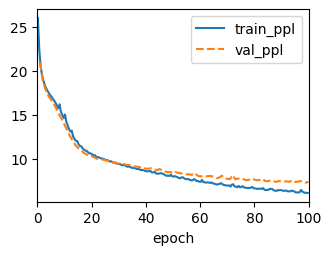

In [4]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
n, v = data.num_train, data.num_val
train_data = TensorDataset(data.X[:n], data.Y[:n])
val_data = TensorDataset(data.X[n:n+v], data.Y[n:n+v])

rnn = RNN(num_inputs=len(data.vocab), num_hiddens=32)
model = RNNLM(rnn, vocab_size=len(data.vocab), lr=1)
trainer = Trainer(max_epoch=100, grad_clip_val=1)

ce = nn.CrossEntropyLoss(reduction="mean")

def loss_fn(pred, y):
    """Flatten (batch_size, num_steps, vocab_size) preds into per-token predictions."""
    return ce(pred.reshape(-1, pred.shape[-1]), y.reshape(-1))

trainer.fit(model, train_data, loss_fn, val_data=val_data, batch_size=1024)
trainer.board.show()

In [ ]:
model.predict('it has', 20, data.vocab)

'it has in the the the the '

In [ ]:
print(model.predict('i love emilia', 20, data.vocab))

<unk> love <unk>milial a dimention so men
